In [1]:
%%time

import os
import shutil
import geopandas as gpd
import numpy as np
import pickle
import pandas as pd
from dea_tools.plotting import display_map, rgb, xr_animation
import matplotlib.pyplot as plt 
from IPython.core.display import Video
from joblib import Parallel, delayed
from tqdm import tqdm
import xarray as xr
import seaborn as sns
import matplotlib.patches as mpatches
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px
from plotly.offline import plot, iplot
import plotly.io as pio
from shapely.geometry import mapping
import json
import statsmodels.api as sm
from scipy.cluster.hierarchy import linkage, leaves_list

CPU times: user 3.39 s, sys: 1.76 s, total: 5.15 s
Wall time: 8.55 s


In [2]:
# I couldn't get this working in my own own environment, so using John's geospatenv environment
import tensorflow as tf
from fractionalcover3 import unmix_fractional_cover 
from fractionalcover3 import data 

2024-08-17 13:09:05.828851: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-08-17 13:09:05.828897: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-08-17 13:09:05.830035: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [3]:
os.chdir('./Projects/PaddockTS')

In [13]:
!ls /g/data/xe2/John/Data/PadSeg/MILG_b033_2017-24*

 /g/data/xe2/John/Data/PadSeg/MILG_b033_2017-24.tif
 /g/data/xe2/John/Data/PadSeg/MILG_b033_2017-24_2017_crop_map_.html
 /g/data/xe2/John/Data/PadSeg/MILG_b033_2017-24_2017_heatmap_dendro_CFI3_namedpaddocks_pt-CFI3.png
 /g/data/xe2/John/Data/PadSeg/MILG_b033_2017-24_2017_heatmap_dendro_NDVI_pt-NDVI.png
 /g/data/xe2/John/Data/PadSeg/MILG_b033_2017-24_2017_time_series.html
 /g/data/xe2/John/Data/PadSeg/MILG_b033_2017-24_2018_crop_map_.html
 /g/data/xe2/John/Data/PadSeg/MILG_b033_2017-24_2018_heatmap_dendro_CFI3_namedpaddocks_pt-CFI3.png
 /g/data/xe2/John/Data/PadSeg/MILG_b033_2017-24_2018_heatmap_dendro_NDVI_pt-NDVI.png
 /g/data/xe2/John/Data/PadSeg/MILG_b033_2017-24_2018_time_series.html
 /g/data/xe2/John/Data/PadSeg/MILG_b033_2017-24_2019_crop_map_.html
 /g/data/xe2/John/Data/PadSeg/MILG_b033_2017-24_2019_heatmap_dendro_CFI3_namedpaddocks_pt-CFI3.png
 /g/data/xe2/John/Data/PadSeg/MILG_b033_2017-24_2019_heatmap_dendro_NDVI_pt-NDVI.png
 /g/data/xe2/John/Data/PadSeg/MILG_b033_2017-24_2019

In [4]:
stub = 'MILG_b033_2017-24'
chris_outdir = "/g/data/xe2/Chris/Data/PadSeg/"
john_outdir =  "/g/data/xe2/John/Data/PadSeg/"  # Chris can read, but can't write to John's directory
outdir = john_outdir
tmp_dir = '/scratch/xe2/cb8590/tmp/'+stub+'/'

# Temporary directory for animations, frames and plots
# clear the tmp directory and create anew
shutil.rmtree(tmp_dir, ignore_errors=True)
os.makedirs(tmp_dir)

paddocks_manual = "/g/data/xe2/John/Data/PadSeg/milg_manualpaddocks2.gpkg" # hand-drawn paddock polygons with name column that MAY match with annotation data (not all rows will have annotations)
paddock_annotations = "/g/data/xe2/John/Data/PadSeg/MILG_paddocks_tmp.csv" # the latest version of paddock management annotation data (assumes format stays the same!)

In [5]:
# Read in the polygons from SAMGeo (these will not neccesarily match user-provided paddocks)
pol = gpd.read_file(outdir+stub+'_filt.gpkg')

# have to set a paddock id. Preferably do this in earlier step in future... 
pol['paddock'] = range(1,len(pol)+1)
pol['paddock'] = pol.paddock.astype('category')

# Read in the array of paddocks by variables (e.g. bands) by time -- the pvt array
pvt = np.load(outdir+stub+'_pvt.npy')
# pvt = np.load(data_path+stub+'_pvt2.npy')

# get the variable names:
with open(outdir+stub+'_pvt_vars.pkl', 'rb') as handle:
    var_names = pickle.load(handle)
print('No. vars:',len(var_names))

No. vars: 23


In [6]:
# Read in manual polygons and paddock annotation data. Merge and keep as a geopandas df:

# paddock annotatioun data:
pad_an = pd.read_csv(paddock_annotations)

# Load the manual drawn polygons GeoDataFrame
pad_man = gpd.read_file(paddocks_manual)

# Remove rows that have no geometry
pad_man = pad_man[pad_man.geometry.notnull()]
print(len(pad_man))

# Identify rows with invalid geometries
invalid_geometries = pad_man[~pad_man.is_valid]
print("Invalid geometries:")
print(invalid_geometries)

# Remove rows with invalid geometries
pad_man = pad_man[pad_man.is_valid]
print("------")
print(len(pad_man))

# Add a new column with unique numbers
pad_man['paddock'] = range(1, len(pad_man) + 1)

# merge manual drawn polygons with annotations
pad_manan = pd.merge(pad_man, pad_an, left_on='name', right_on='Name', how='left').drop(columns=['Name'])
print(pad_manan.crs)
print(len(pad_manan), len(pad_man), len(pad_an))

90
Invalid geometries:
   name    type                                           geometry
86  fr1  forest  POLYGON ((14325498.506 -4132100.273, 14325511....
------
89
EPSG:6933
89 89 28


In [7]:
# Add colors to plot the polygons with:
# Create the 'color' column and set it to None for all rows
pad_man['color'] = 'None'

# Define the conditions and corresponding values for 'edge_color'
conditions = [
    (pad_man['type'] == 'forest'),
    (pad_man['type'] == 'tree_row'),
    (pad_man['type'] == 'named'),
    (pad_man['type'] == 'unnamed'),
    # Add more conditions here if needed
]

values = ['green', 'yellow', 'red', 'blue']
# Add corresponding values for additional conditions here if needed

# Create the 'edge_color' column based on the conditions
pad_man['edge_color'] = np.select(conditions, values, default='other')
print(pad_man)

    name      type                                           geometry  \
0   None   unnamed  POLYGON ((14324740.000 -4132290.000, 14324760....   
1   None   unnamed  POLYGON ((14324120.000 -4132270.000, 14324140....   
2   None   unnamed  POLYGON ((14323570.000 -4132320.000, 14323710....   
3   None   unnamed  POLYGON ((14324930.000 -4132490.000, 14325020....   
4   None   unnamed  POLYGON ((14324990.000 -4132750.000, 14325110....   
..   ...       ...                                                ...   
84  tr21  tree_row  POLYGON ((14325892.173 -4136177.198, 14326086....   
85  tr22  tree_row  POLYGON ((14325452.296 -4135098.629, 14325451....   
87   fr2    forest  POLYGON ((14326017.563 -4132451.584, 14326094....   
88   fr3    forest  POLYGON ((14327713.350 -4135076.423, 14327951....   
89   fr4    forest  POLYGON ((14327730.392 -4135936.597, 14328102....   

    paddock color edge_color  
0         1  None       blue  
1         2  None       blue  
2         3  None       blue  

In [8]:
# Check memory usage
import resource

def memory_usage():
    usage = resource.getrusage(resource.RUSAGE_SELF)
    return f"Memory usage: {usage.ru_maxrss / 1024} MB"

print(memory_usage())
# Loading in the data was 35GB
# After doing the calendar plots, went up to 45GB

Memory usage: 574.1875 MB


In [9]:
%%time

# Open the satellite data stack. Takes about 1 min 30 secs when using XX_LargeMem.
with open(john_outdir+stub+'_ds2.pkl', 'rb') as handle:
    ds_full = pickle.load(handle)

memory_usage()

CPU times: user 133 ms, sys: 26.6 s, total: 26.8 s
Wall time: 46.5 s


'Memory usage: 27898.73828125 MB'

In [10]:
ds = ds_full

In [11]:
# # Filter to a single year
# year = 2019
# ds = ds_full.sel(time=ds_full['time'].dt.year == year)

In [11]:
%%time

# Resample data weekly
ds_weekly = ds.resample(time="1W").interpolate("linear")

print('No. weeks in time series:', len(ds_weekly.time.values))
ds_weekly

No. weeks in time series: 363
CPU times: user 37.9 s, sys: 43.3 s, total: 1min 21s
Wall time: 1min 21s


<xarray.Dataset>
Dimensions:                     (y: 699, x: 638, time: 363)
Coordinates:
  * y                           (y) float64 -4.132e+06 -4.132e+06 ... -4.139e+06
  * x                           (x) float64 1.432e+07 1.432e+07 ... 1.433e+07
    spatial_ref                 int32 6933
  * time                        (time) datetime64[ns] 2017-01-15 ... 2023-12-24
Data variables: (12/40)
    nbart_coastal_aerosol       (time, y, x) float64 nan nan nan ... nan nan nan
    nbart_blue                  (time, y, x) float64 nan nan nan ... nan nan nan
    nbart_green                 (time, y, x) float64 nan nan nan ... nan nan nan
    nbart_red                   (time, y, x) float64 nan nan nan ... nan nan nan
    nbart_red_edge_1            (time, y, x) float64 nan nan nan ... nan nan nan
    nbart_red_edge_2            (time, y, x) float64 nan nan nan ... nan nan nan
    ...                          ...
    NDWI                        (time, y, x) float64 nan nan nan ... nan nan nan
    MNDWI                       (time, y, x) float64 nan nan nan ... nan nan nan
    NBR                         (time, y, x) float64 nan nan nan ... nan nan nan
    NDCI                        (time, y, x) float64 nan nan nan ... nan nan nan
    NDTI                        (time, y, x) float64 nan nan nan ... nan nan nan
    BSI                         (time, y, x) float64 nan nan nan ... nan nan nan
Attributes:
    crs:           epsg:6933
    grid_mapping:  spatial_ref

In [12]:
ds_weekly

<xarray.Dataset>
Dimensions:                     (y: 699, x: 638, time: 363)
Coordinates:
  * y                           (y) float64 -4.132e+06 -4.132e+06 ... -4.139e+06
  * x                           (x) float64 1.432e+07 1.432e+07 ... 1.433e+07
    spatial_ref                 int32 6933
  * time                        (time) datetime64[ns] 2017-01-15 ... 2023-12-24
Data variables: (12/40)
    nbart_coastal_aerosol       (time, y, x) float64 nan nan nan ... nan nan nan
    nbart_blue                  (time, y, x) float64 nan nan nan ... nan nan nan
    nbart_green                 (time, y, x) float64 nan nan nan ... nan nan nan
    nbart_red                   (time, y, x) float64 nan nan nan ... nan nan nan
    nbart_red_edge_1            (time, y, x) float64 nan nan nan ... nan nan nan
    nbart_red_edge_2            (time, y, x) float64 nan nan nan ... nan nan nan
    ...                          ...
    NDWI                        (time, y, x) float64 nan nan nan ... nan nan nan
    MNDWI                       (time, y, x) float64 nan nan nan ... nan nan nan
    NBR                         (time, y, x) float64 nan nan nan ... nan nan nan
    NDCI                        (time, y, x) float64 nan nan nan ... nan nan nan
    NDTI                        (time, y, x) float64 nan nan nan ... nan nan nan
    BSI                         (time, y, x) float64 nan nan nan ... nan nan nan
Attributes:
    crs:           epsg:6933
    grid_mapping:  spatial_ref

In [21]:
%%time

# Function to process each geometry row
def process_geometry(datarow, ds):
    import rioxarray
    """
    Process each geometry to extract the median band values.
    Args:
        datarow: A row from the geopandas dataframe containing the geometry.
        ds: The xarray dataset with time series satellite imagery.
    Returns:
        A numpy array of median band values for the geometry over time.
    """
    # Clip the xarray dataset to the polygon
    ds_clipped = ds.rio.clip([datarow.geometry])

    # Extract the median band value, ignoring zero values
    pol_ts = ds_clipped.where(ds_clipped > 0).median(dim=['x', 'y'])
    array = pol_ts.to_array().transpose('variable', 'time').values.astype(np.float32)

    return array[None, :]

# # Define the function
# def process_chunk(chunk, ds_weekly):
#     results = [process_geometry(row, ds_weekly) for row in chunk.itertuples(index=True)]
#     return results


# # Trying to process in chunks to avoid the pickle limit
# def process_in_chunks(df, chunk_size, ds_weekly):
#     num_chunks = (len(df) + chunk_size - 1) // chunk_size
#     chunks = [df[i*chunk_size:(i+1)*chunk_size] for i in range(num_chunks)]
    
#     results = Parallel(n_jobs=-1)(
#         delayed(process_chunk)(chunk, ds_weekly)
#         for chunk in tqdm(chunks, total=num_chunks)
#     )
#     return [item for sublist in results for item in sublist]

# chunk_size = 10  # Adjust chunk size based on memory constraints
# results = process_in_chunks(pad_man, chunk_size, ds_weekly)


# # Use parallel processing to extract time series data for each paddock
# results = Parallel(n_jobs=-1)(
#     delayed(process_geometry)(datarow, ds_weekly) 
#     for datarow in tqdm(pad_man.itertuples(index=True), total=len(pad_man))
# )


# Don't use parallel processing because it was running into errors
results = []
for datarow in tqdm(pad_man.itertuples(index=True), total=len(pad_man)):
    result = process_geometry(datarow, ds_weekly)
    results.append(result)

100%|██████████| 89/89 [31:40<00:00, 21.36s/it]

CPU times: user 10min 13s, sys: 21min 25s, total: 31min 38s
Wall time: 31min 40s


In [22]:
# Combine the results into a single numpy array
pvt = np.vstack([res for res in results])

print("Processing complete")  # Took 10 secs with hugemem
print("pvt shape: ", pvt.shape)

Processing complete
pvt shape:  (89, 40, 363)


In [25]:
print(memory_usage())

Memory usage: 119258.9609375 MB


In [26]:
np.save(chris_outdir + stub + '_pvt_manual', pvt, allow_pickle=True, fix_imports=True)


In [27]:
pvt = np.load(chris_outdir+stub+'_pvt_manual.npy')
pvt.shape

(89, 40, 363)

In [29]:

# This version is for calculating fractional cover per paddock. The other version is to calculate it for the whole xarray.
def calculate_fractional_cover_paddocks(ds):
    """
    Calculate the fractional cover 
    gitlab repo: https://gitlab.com/jrsrp/themes/cover/fractionalcover3/-/blob/master/src/fractionalcover3/unmixcover.py
    """
    band_names=['nbart_blue', 'nbart_green', 'nbart_red', 'nbart_nir_1', 'nbart_swir_2', 'nbart_swir_3'] 
    model=3  # This model gave the greatest differentiation in my preliminary testing

    scaling_factor = 0.0001
    
    blue =  ds.sel(variable='nbart_blue').pvt  * scaling_factor
    green =  ds.sel(variable='nbart_green').pvt * scaling_factor
    red =  ds.sel(variable='nbart_red').pvt * scaling_factor
    nir1 =  ds.sel(variable='nbart_nir_1').pvt * scaling_factor
    swir1 = ds.sel(variable='nbart_swir_2').pvt * scaling_factor
    swir2 = ds.sel(variable='nbart_swir_3').pvt * scaling_factor
    
    bare = np.zeros(blue.shape)
    photosynthetic = np.zeros(blue.shape)
    non_photosynthetic = np.zeros(blue.shape)
    
    # Loop over each paddock time and apply the unmix_fractional_cover function
    for paddock in range(blue.shape[0]):
        for time in range(blue.shape[1]):
            pt_blue = blue[paddock, time].values
            pt_green = green[paddock, time].values
            pt_red = red[paddock, time].values
            pt_nir1 = nir1[paddock, time].values
            pt_swir1 = swir1[paddock, time].values
            pt_swir2 = swir2[paddock, time].values
            
            surface_reflectance = np.array([pt_blue, pt_green, pt_red, pt_nir1, pt_swir1, pt_swir2])
            surface_reflectance2 = surface_reflectance.reshape([6,1,1])
            unmixed = unmix_fractional_cover(surface_reflectance2, fc_model=data.get_model(n=model))

            unmixed[np.where(np.isinf(unmixed))] = np.nan
    
            bare[paddock][time] = unmixed[0][0][0]
            photosynthetic[paddock][time] = unmixed[1][0][0]
            non_photosynthetic[paddock][time] = unmixed[2][0][0]

    return bare, photosynthetic, non_photosynthetic
    


In [30]:
%%time

# Create ds_paddocks
#Function to add spectral indices to an xarray
def calculate_indices(ds, indices, fractional_cover=True):
    """
    Calculate multiple indices and add them to the dataset, retaining all data variables.
    
    Parameters:
    ds (xarray.Dataset): The input xarray dataset with dimensions (paddock, variable, time)
    indices (dict): A dictionary where keys are the names of the indices to be added, 
                    and values are functions that calculate the index.
    
    Returns:
    xarray.Dataset: The dataset with the additional indices and all original data variables.
    """
    new_bands = []

    for index_name, index_func in indices.items():
        # Calculate the index
        index_data = index_func(ds)
        
        # Expand dimensions of the new index to match the original dataset structure
        index_expanded = index_data.expand_dims(variable=[index_name], axis=1)
        
        # Append the new index to the list
        new_bands.append(index_expanded)
        print(index_name, 'has shape: ', index_data.shape)

    # Doing the fractional cover separately because it returns three bands
    if fractional_cover:
        blue = ds.sel(variable='nbart_blue').pvt  # Choosing an arbitrary band to match the coords and dim
        
        bare, photosynthetic, non_photosynthetic = calculate_fractional_cover_paddocks(ds)
        bare_data = xr.DataArray(bare, coords=blue.coords, dims=blue.dims)
        bare_expanded = bare_data.expand_dims(variable=['bare'], axis=1)
        
        photosynthetic_data = xr.DataArray(photosynthetic, coords=blue.coords, dims=blue.dims)
        photosynthetic_expanded = photosynthetic_data.expand_dims(variable=['photosynthetic'], axis=1)
        
        non_photosynthetic_data = xr.DataArray(non_photosynthetic, coords=blue.coords, dims=blue.dims)
        non_photosynthetic_expanded = non_photosynthetic_data.expand_dims(variable=['non_photosynthetic'], axis=1)
        
        new_bands.append(bare_expanded)
        new_bands.append(photosynthetic_expanded)
        new_bands.append(non_photosynthetic_expanded)

        print('bare has shape: ', bare_data.shape)
        print('photosynthetic has shape: ', photosynthetic_data.shape)
        print('non_photosynthetic has shape: ', non_photosynthetic_data.shape)

    # Concatenate all new indices along the variable dimension
    new_bands_concat = xr.concat([ds.pvt] + new_bands, dim='variable').to_dataset(name='pvt')

    # Add back all original data variables to the new dataset
    for var in ds.data_vars:
        if var != 'pvt':  # Avoid overwriting the 'pvt' variable
            new_bands_concat[var] = ds[var]
    
    return new_bands_concat

def calculate_ndyi(ds):
    '''Yellowness index
    suggested to identify flowering of canola and other yellow-flowered plants
    https://custom-scripts.sentinel-hub.com/custom-scripts/sentinel-2/ndyi/
    '''
    blue = ds.sel(variable='nbart_blue').pvt
    green = ds.sel(variable='nbart_green').pvt
    ndyi = (green - blue) / (blue + green)
    return ndyi

def calculate_ndyi2(ds):
    '''Yellowness index (NEW)
    '''
    red = ds.sel(variable='nbart_red').pvt
    green = ds.sel(variable='nbart_green').pvt
    ndvi = ds.sel(variable='NDVI').pvt
    ndyi2 = (red + green) / ndvi

    # Normalize between 0 and 1
    min = ndyi2.min()
    max = ndyi2.max()
    ndyi2_norm = (ndyi2 - min) / (max - min)
    return ndyi2_norm

def calculate_cfi3(ds):
    '''Calculate CFI3 (Canola Flower Index 3)
    Tian et al 2022 Remote Sensing https://www.mdpi.com/2072-4292/14/5/1113#sec2dot4-remotesensing-14-01113'''
    ndvi = ds.sel(variable='NDVI').pvt
    red = ds.sel(variable='nbart_red').pvt
    green = ds.sel(variable='nbart_green').pvt
    blue = ds.sel(variable='nbart_blue').pvt
    
    sum_red_green = red + green
    diff_green_blue = green - blue
    
    cfi3 = ndvi * (sum_red_green + diff_green_blue)
    return cfi3

def calculate_nirv(ds):
    '''Near Infrared Reflectance of Vegetation
    '''
    ndvi = ds.sel(variable='NDVI').pvt
    nir = ds.sel(variable='nbart_nir_1').pvt
    nirv = ndvi * nir
    return nirv

def calculate_dnirv(ds):
    '''Calculate difference in NIRv compared to previous time step
    Caution: this seems to remove one time step'''
    nirv = calculate_nirv(ds)
    dnirv = nirv.diff(dim='time', n=1)
    #dnirv = xr.concat([xr.DataArray([0], dims='time'), dnirv], dim='time')  # Handle first time step (make dnirv equal to zero)
    return dnirv

def calculate_ndti(ds):
    """ Normalized Difference Tillage Index (NDTI).
    NDTI = (R1610−R2200)/(R1610 + R2200)
    Described here and ref within: https://www.mdpi.com/2072-4292/13/18/3718 
    """
    # Extract the SWIR1 and SWIR2 bands
    swir1 = ds.sel(variable='nbart_swir_2').pvt
    swir2 = ds.sel(variable='nbart_swir_3').pvt
    
    # Calculate the NDTI
    ndti = (swir1 - swir2) / (swir1 + swir2)
    
    return ndti

def calculate_cai(ds):
    """Cellulose Absorption Index (CAI).
    CAI = (0.5∗(R2000 +R2200))−R2100
    see https://www.mdpi.com/2072-4292/13/18/3718 
    see also for calibration/nuance with Sentinel data: https://www.spiedigitallibrary.org/conference-proceedings-of-spie/11155/2533761/Identification-of-non-photosynthetic-vegetation-areas-in-Sentinel-2-satellite/10.1117/12.2533761.full
    """
    # Extract the SWIR1, SWIR2, and NIR bands
    swir1 = ds.sel(variable='nbart_swir_2').pvt
    swir2 = ds.sel(variable='nbart_swir_3').pvt
    nir = ds.sel(variable='nbart_nir_1').pvt
    
    # Calculate the CAI
    cai = 0.5 * (swir1 + swir2) - nir
    
    return cai

# get new indices:
indices = {
    'NDYI': calculate_ndyi,
    'NDYI2': calculate_ndyi2,
    'CFI3': calculate_cfi3,
    'NIRv': calculate_nirv,
    'dNIRv': calculate_dnirv,
    'NDTI2': calculate_ndti,
    'CAI': calculate_cai,
}

def create_paddock_xarray(pol, pvt_array, ds):
    '''TO DO
    remove valid_crown_ids
    '''
    # Extract time axis from the xarray Dataset
    time_axis = ds.time

    # get variable names (bands)
    var_names = list(ds.data_vars.keys())

    # Create a DataArray for the paddock geometries
    geometry_da = xr.DataArray(pol.geometry.values, dims=["paddock"], name="geometry")

    # Create DataArrays for additional variables
    name_da = xr.DataArray(pol.name.values, dims=["paddock"], name="name")
    type_da = xr.DataArray(pol['type'].values, dims=["paddock"], name="type")

    # Create DataArray for each band over time
    pvt_da = xr.DataArray(
        pvt_array,
        dims=["paddock", "variable", "time"],
        coords={
            "paddock": pol.paddock.values,
            "variable": var_names,
            "time": time_axis
        },
        name="pvt"
    )

    # Combine into a single Dataset
    ds_paddocks = xr.Dataset({
        "geometry": geometry_da,
        "name": name_da,
        "type": type_da,
        "pvt": pvt_da
    })

    return ds_paddocks

ds_weekly_paddocks = create_paddock_xarray(pad_man, pvt, ds_weekly)
ds_weekly_paddocks = calculate_indices(ds_weekly_paddocks, indices)
print(ds_weekly_paddocks)

NDYI has shape:  (89, 363)
NDYI2 has shape:  (89, 363)
CFI3 has shape:  (89, 363)
NIRv has shape:  (89, 363)
dNIRv has shape:  (89, 362)
NDTI2 has shape:  (89, 363)
CAI has shape:  (89, 363)


INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


bare has shape:  (89, 363)
photosynthetic has shape:  (89, 363)
non_photosynthetic has shape:  (89, 363)
<xarray.Dataset>
Dimensions:   (paddock: 89, time: 363, variable: 50)
Coordinates:
  * paddock   (paddock) int64 1 2 3 4 5 6 7 8 9 ... 81 82 83 84 85 86 87 88 89
  * time      (time) datetime64[ns] 2017-01-15 2017-01-22 ... 2023-12-24
  * variable  (variable) object 'nbart_coastal_aerosol' ... 'non_photosynthetic'
Data variables:
    pvt       (paddock, variable, time) float64 nan 464.7 506.5 ... 0.4928 nan
    geometry  (paddock) object POLYGON ((14324740 -4132290, 14324760 -4132290...
    name      (paddock) object None None None None ... 'tr22' 'fr2' 'fr3' 'fr4'
    type      (paddock) object 'unnamed' 'unnamed' ... 'forest' 'forest'
CPU times: user 1min 7s, sys: 6.28 s, total: 1min 14s
Wall time: 1min 30s


In [31]:
outdir = chris_outdir

In [32]:
with open(outdir+stub+'_ds_weekly_paddocks_'+'all_years'+'.pkl', 'wb') as handle:
    pickle.dump(ds_weekly_paddocks, handle, protocol=pickle.HIGHEST_PROTOCOL)


In [33]:
pd.set_option('display.max_rows', 100)  # Adjust the number 100 as needed
pd.set_option('display.max_columns', 100)  # Adjust the number 100 as needed

In [57]:
# Cleaning the management table
# named_paddocks = pad_manan[pad_manan['type'] == 'named']
named_paddocks = pad_manan

# Remove columns we don't need
named_dropped = named_paddocks.drop(columns=["type", "geometry", '2020_Impr. Graz Man', '2018_Cover Crops', "paddock", '2019_Pasture Improv', '2019_Cover Crops', '2021_Pasture Improv', '2019_Impr. Graz Man',  'Arable Area (ha)', 'Soil Tested', 'CMB applied', '2025_Crop', '2017_Cover Crops', '2017_Pasture Improv', '2018_Impr. Graz Man', '2017_Impr. Graz Man', '2025_Pasture Improv', '2025_Impr. Graz Man', '2025_Cover Crops', '2024_Crop', '2024_Pasture Improv', '2024_Impr. Graz Man',
       '2024_Cover Crops', '2023_Impr. Graz Man'])
named_dropped.rename(columns={' 2021 Crop': '2021_Crop'}, inplace=True)
named_dropped = named_dropped.fillna('')

# Cleanup 'x' values with the column name
years = ['2017', '2018', '2019', '2020', '2021', '2022', '2023']
for year in years:
    column = f'{year}_Pasture Improv'
    if column in named_dropped:
        named_dropped[column] = named_dropped[column].replace('x', 'Improved Pasture')
        
    column = f'{year}_Impr. Graz Man'
    if column in named_dropped:
        named_dropped[column] = named_dropped[column].replace('x', 'Managed Grazing')

    column = f'{year}_Cover Crops'
    if column in named_dropped:
        named_dropped[column] = named_dropped[column].replace('x', 'Cover Crop')

# There are two columns for 2021. Rename one of them to make them unique
unduplicated_columns = list(named_dropped.columns)
unduplicated_columns[1] = '2021_Crop_2'
named_dropped.columns = unduplicated_columns

# Remove whitespaces
named_dropped = named_dropped.astype(str)
for column in named_dropped:
    named_dropped[column].apply(lambda x: x.strip() if isinstance(x, str) else x)

# Combine management actions into a single column per year
for year in years:
    # suffixes = '_Crop', '_Crop_2',  '_Pasture Improv', '_Impr. Graz Man', '_Cover Crops'
    suffixes = '_Crop', '_Crop_2', '_Cover Crops'
    columns = []
    for suffix in suffixes:
        column = f'{year}{suffix}'
        if column in named_dropped:
            columns.append(column)
    named_dropped[year] = named_dropped[columns].apply(lambda x: ', '.join(x).strip().strip(",").strip().strip(",").strip().strip(","), axis=1)

named_dropped.rename(columns={'name': 'Name'}, inplace=True)
final_columns = ['2017', '2018', '2019',
       '2020', '2021', '2022', '2023', 'Pasture State', 'Name']
df = named_dropped[final_columns]
df = df.sort_values(['Name'])
df

,2017,2018,2019,2020,2021,2022,2023,Pasture State,Name
0,,,,,,,,,
21,,,,,,,,,
22,,,,,,,,,
23,,,,,,,,,
24,,,,,,,,,
25,,,,,,,,,
26,,,,,,,,,
27,,,,,,,,,
20,,,,,,,,,
28,,,,,,,,,


In [58]:
paddock_types = pad_manan[['name', 'type', 'Pasture State']]
paddock_types.loc[paddock_types['name'].isnull(), 'name'] = paddock_types['type']
paddock_types.loc[paddock_types['type'] == 'tree_row', 'name'] = 'tree_row'
paddock_types.loc[paddock_types['type'] == 'forest', 'name'] = 'forest'
paddock_types.rename(columns={'name': 'Name'}, inplace=True)
# df = paddock_types[['Name']]
df_sorted = paddock_types.fillna('').sort_values(['Pasture State', 'Name'])

/jobfs/123085854.gadi-pbs/ipykernel_3989307/1978390691.py:5: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [136]:
df_subset = df_sorted.loc[[52, 53, 46, 43, 81, 82, 83, 84, 86, 87, 88]]
# df_subset = df_sorted.loc[[43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53]]

[31 27 21 25 15 19 52 10  7  9 11 62 53 34 35 36 23 17  0  3 48 30 32 16
 46 57 51 59 60 41 42 22 29 24 74 80 88 86 87 83 28 75 77 76 85 78 69 82
 84 63 64 67 65 66 72 73 70 71 68 81 55 79 26  2 58 12  4  5 20 56 40 43
 54 18 50 33 61 38 39 47 45 44 49 14 13  6  8  1 37]
/g/data/xe2/Chris/Data/PadSeg/MILG_b033_2017-24_pt-fractional.png


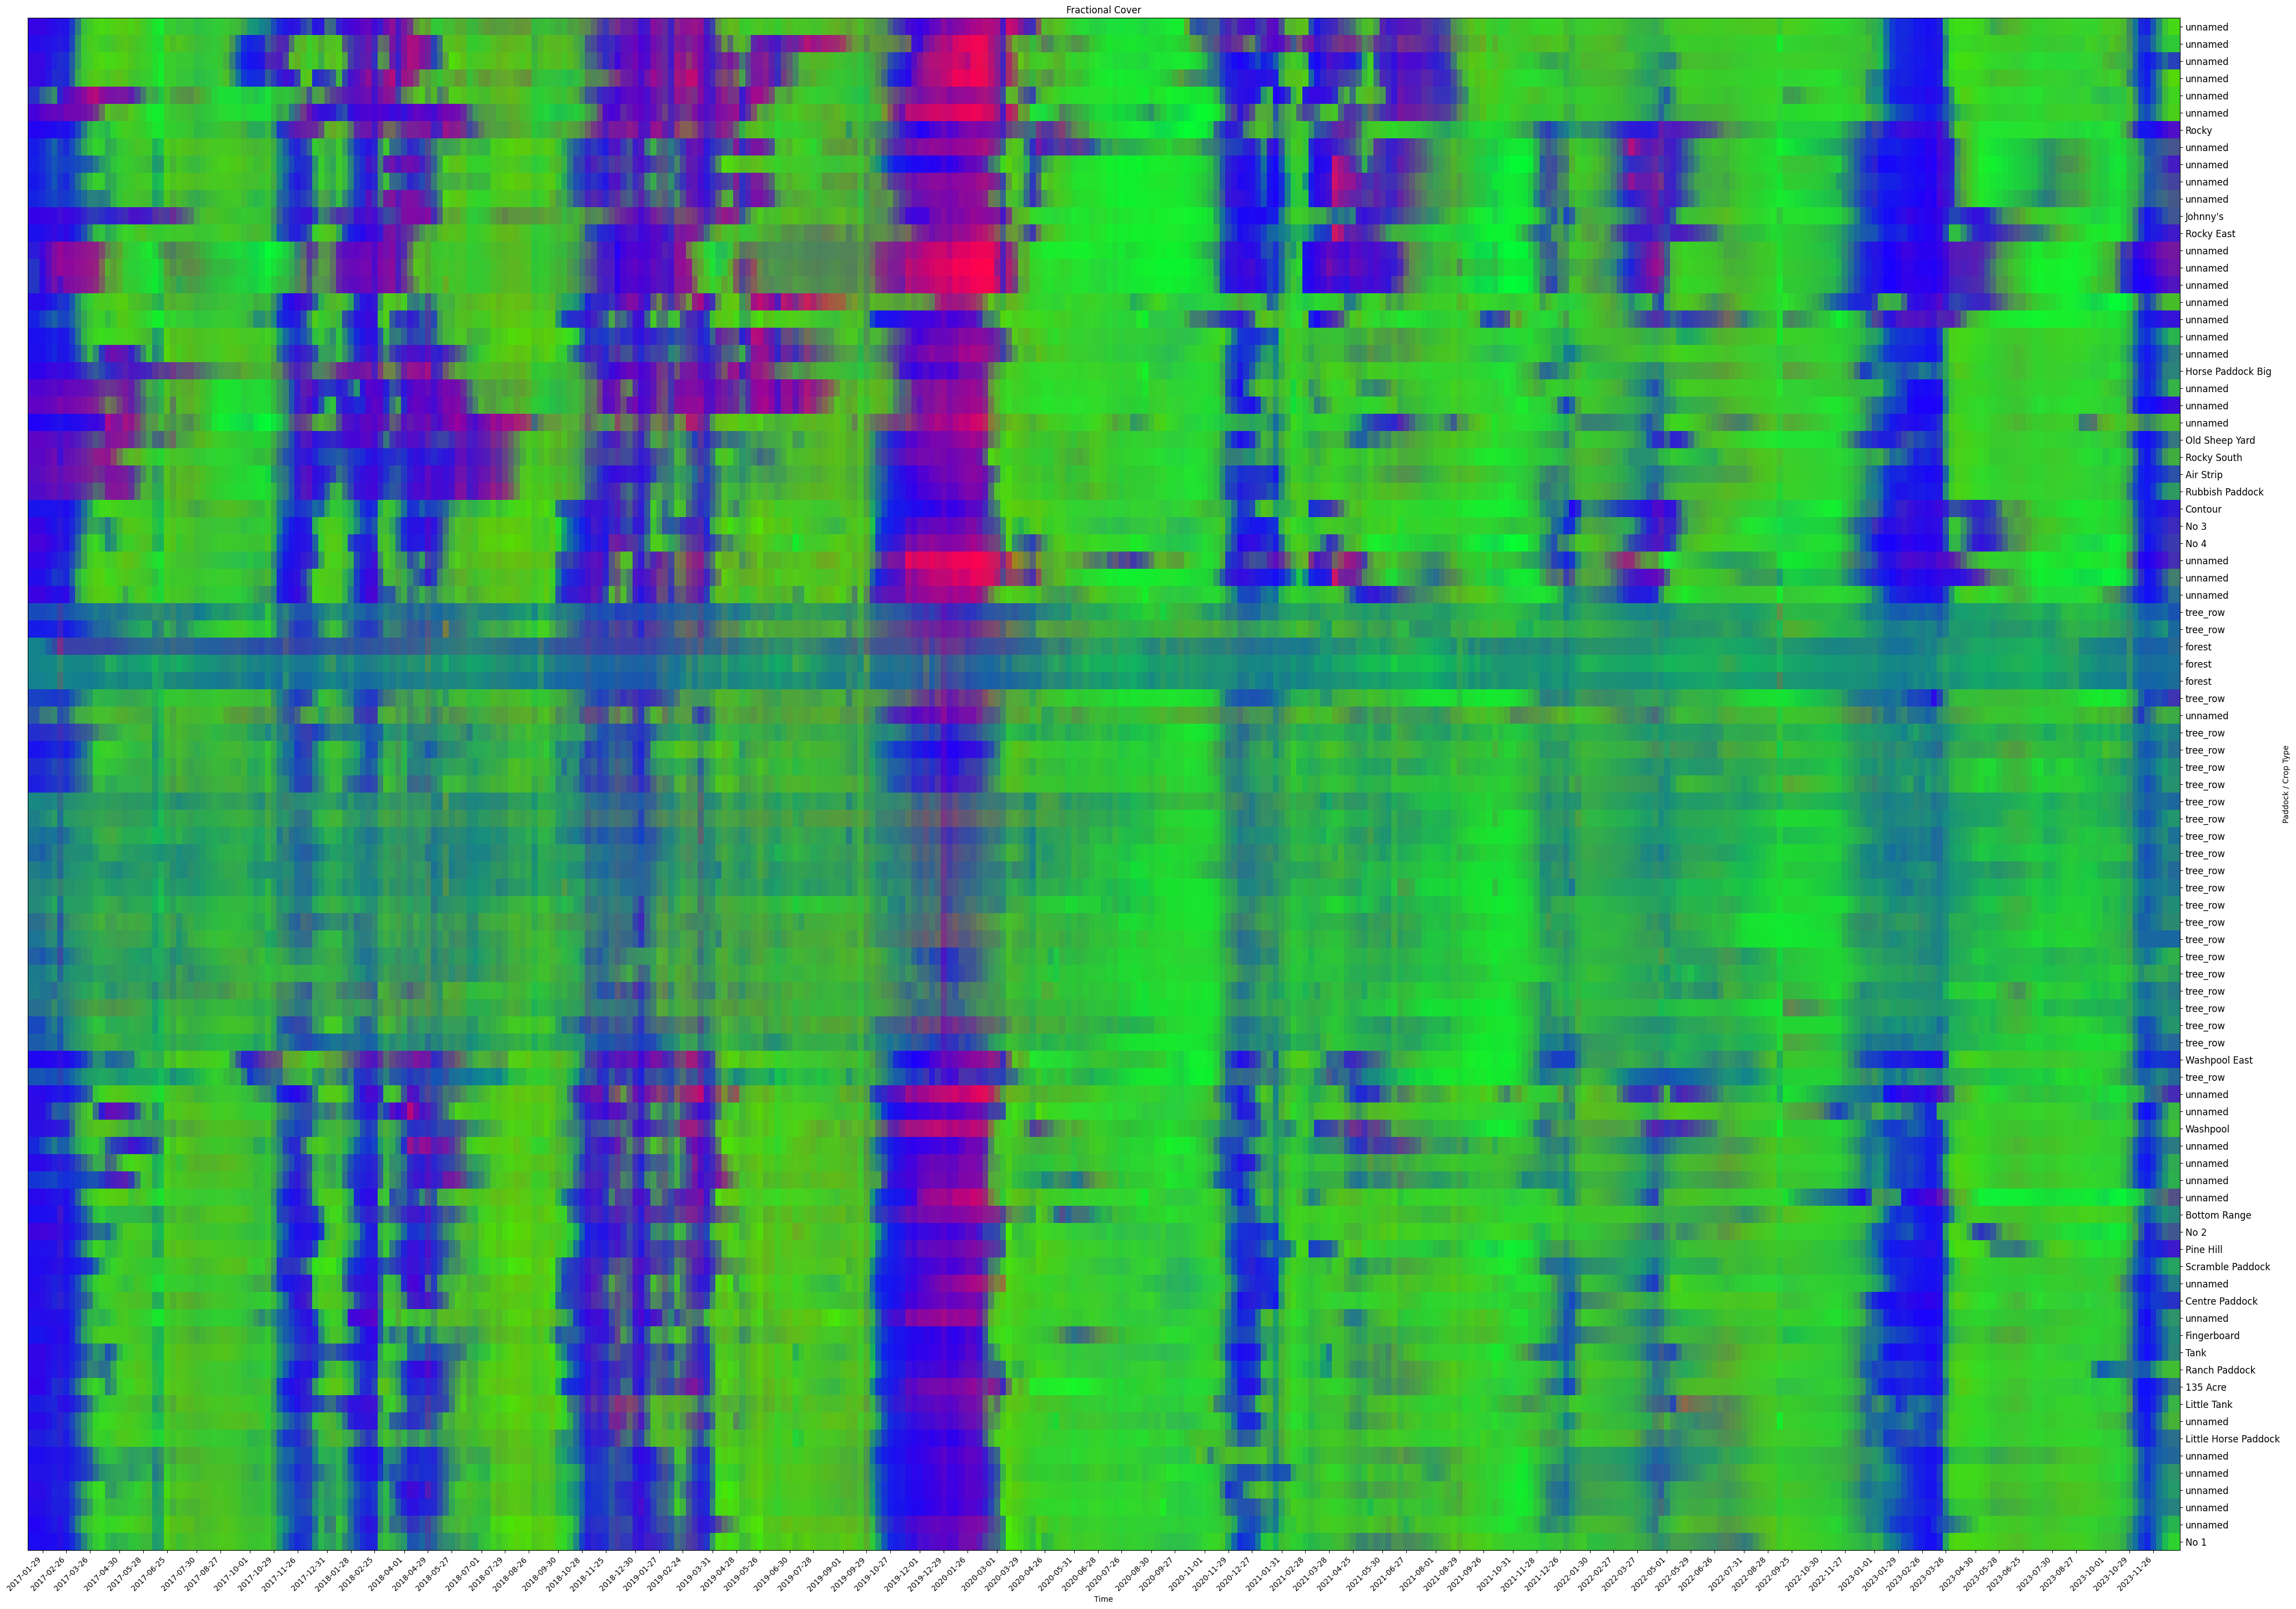

In [70]:
# # Create some row names for consistency across years
# ds_weekly_paddocks_named = ds_weekly_paddocks.where(ds_weekly_paddocks['type'] == 'named', drop=True)
# plot_clustermap_frac(ds_paddocks=ds_weekly_paddocks_named, variable_names=['bare', 'photosynthetic', 'non_photosynthetic'], exaggerate=True)
# ds_paddocks=ds_weekly_paddocks_named
ds_paddocks=ds_weekly_paddocks
variable_names=['bare', 'photosynthetic', 'non_photosynthetic']
exaggerate=True


pt_variables = []
for variable in variable_names:
    pt_variable = ds_paddocks.sel(variable=variable).pvt.values
    pt_variable = np.apply_along_axis(
        lambda x: pd.Series(x).interpolate(method='linear', limit_direction='both').to_numpy(), 
        axis=1, 
        arr=pt_variable
    )
    pt_variable = np.nan_to_num(pt_variable, nan=0)
    pt_variables.append(pt_variable)

pt_bare = pt_variables[0]
pt_photosynthetic = pt_variables[1]
pt_non_photosynthetic = pt_variables[2]

if exaggerate:
    # This exaggerate any variables that don't show up much
    pt_bare_norm = (pt_bare - pt_bare.min()) / (pt_bare.max() - pt_bare.min())
    pt_photosynthetic_norm = (pt_photosynthetic - pt_photosynthetic.min()) / (pt_photosynthetic.max() - pt_photosynthetic.min())
    pt_non_photosynthetic_norm = (pt_non_photosynthetic - pt_non_photosynthetic.min()) / (pt_non_photosynthetic.max() - pt_non_photosynthetic.min())
    rgb_image = np.dstack((pt_bare_norm, pt_photosynthetic_norm, pt_non_photosynthetic_norm))
else:
    rgb_image = np.dstack((pt_bare, pt_photosynthetic, pt_non_photosynthetic))
        
# Extract the timestamps and convert to Pandas DatetimeIndex
time_stamps = ds_paddocks.time.values
time_index = pd.to_datetime(time_stamps)

# Adjust start date to include January if necessary
start_date = time_index.min()
if start_date.month != 1:
    start_date = pd.Timestamp(year=start_date.year, month=1, day=1)

# Ensure January is included in monthly_start
monthly_start = pd.date_range(start=start_date, end=time_index.max(), freq='MS')

# Find the closest previous timestamps in the original time_index
monthly_ticks = []
for date in monthly_start:
    prior_dates = time_index[time_index <= date]
    if not prior_dates.empty:
        monthly_ticks.append(prior_dates[-1])

monthly_ticks_str = [str(t)[:10] for t in monthly_ticks]

# Extract the crop type information for the specified year
# crop_col = f'{year}_Crop'
# the_crops = pad_manan[pad_manan['type'] == 'named'][crop_col].fillna('')
# the_crops = the_crops.apply(lambda x: x.strip() if isinstance(x, str) else x).replace('', '')

# Get paddock names
row_names = ds_paddocks.name.values

names_crops = row_names  # We could add more info here about each paddock
df = df_sorted


# # # Order the rows by clustering
Z = linkage(pt_photosynthetic, method='average', metric='euclidean')
row_order = leaves_list(Z)
ordered_row_names = list(df['Name'][row_order])

# # # Order the rows alphabetically
# row_order = df.index.to_list()
# ordered_row_names = list(df['Name'])

# Reorder the RGB image
rgb_image_ordered = rgb_image[row_order, :, :]
print(row_order)
    
# Calculate the aspect ratio
num_rows, num_cols = rgb_image_ordered.shape[:2]
aspect_ratio = ((num_cols / num_rows)/ 5) * 89/25
# aspect_ratio = ((num_cols / num_rows)/ 5)


# Plot the RGB heatmap
fig, ax = plt.subplots(figsize=(50, 50))
im = ax.imshow(rgb_image_ordered, aspect=aspect_ratio)

# Customize the plot
font_size = 12
ax.set_xticks(ticks=[time_index.get_loc(t) for t in monthly_ticks])
ax.set_xticklabels(monthly_ticks_str, rotation=45, ha='right')

# Set the y-ticks on the right side
ax.yaxis.tick_right()
ax.yaxis.set_label_position('right')
ax.set_yticks(ticks=np.arange(len(ordered_row_names)), labels=ordered_row_names, fontsize=8, rotation=0)
ax.set_yticklabels(ordered_row_names, fontsize=font_size, rotation=0)

# Set labels and title
ax.set_xlabel('Time')
ax.set_ylabel('Paddock / Crop Type')
ax.set_title('Fractional Cover')
ax.grid(False)

# Save the plot to results
filename = outdir + stub + f"_pt-{'fractional'}.png"
plt.savefig(filename, bbox_inches='tight')
print(filename)

[39, 38, 86, 87, 88, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 44, 62, 42, 52, 53, 58, 55, 47, 51, 56, 50, 60, 61, 48, 49, 45, 37, 40, 41, 46, 43, 57, 59, 54]
/g/data/xe2/Chris/Data/PadSeg/MILG_b033_2017-24_pt-fractional.png


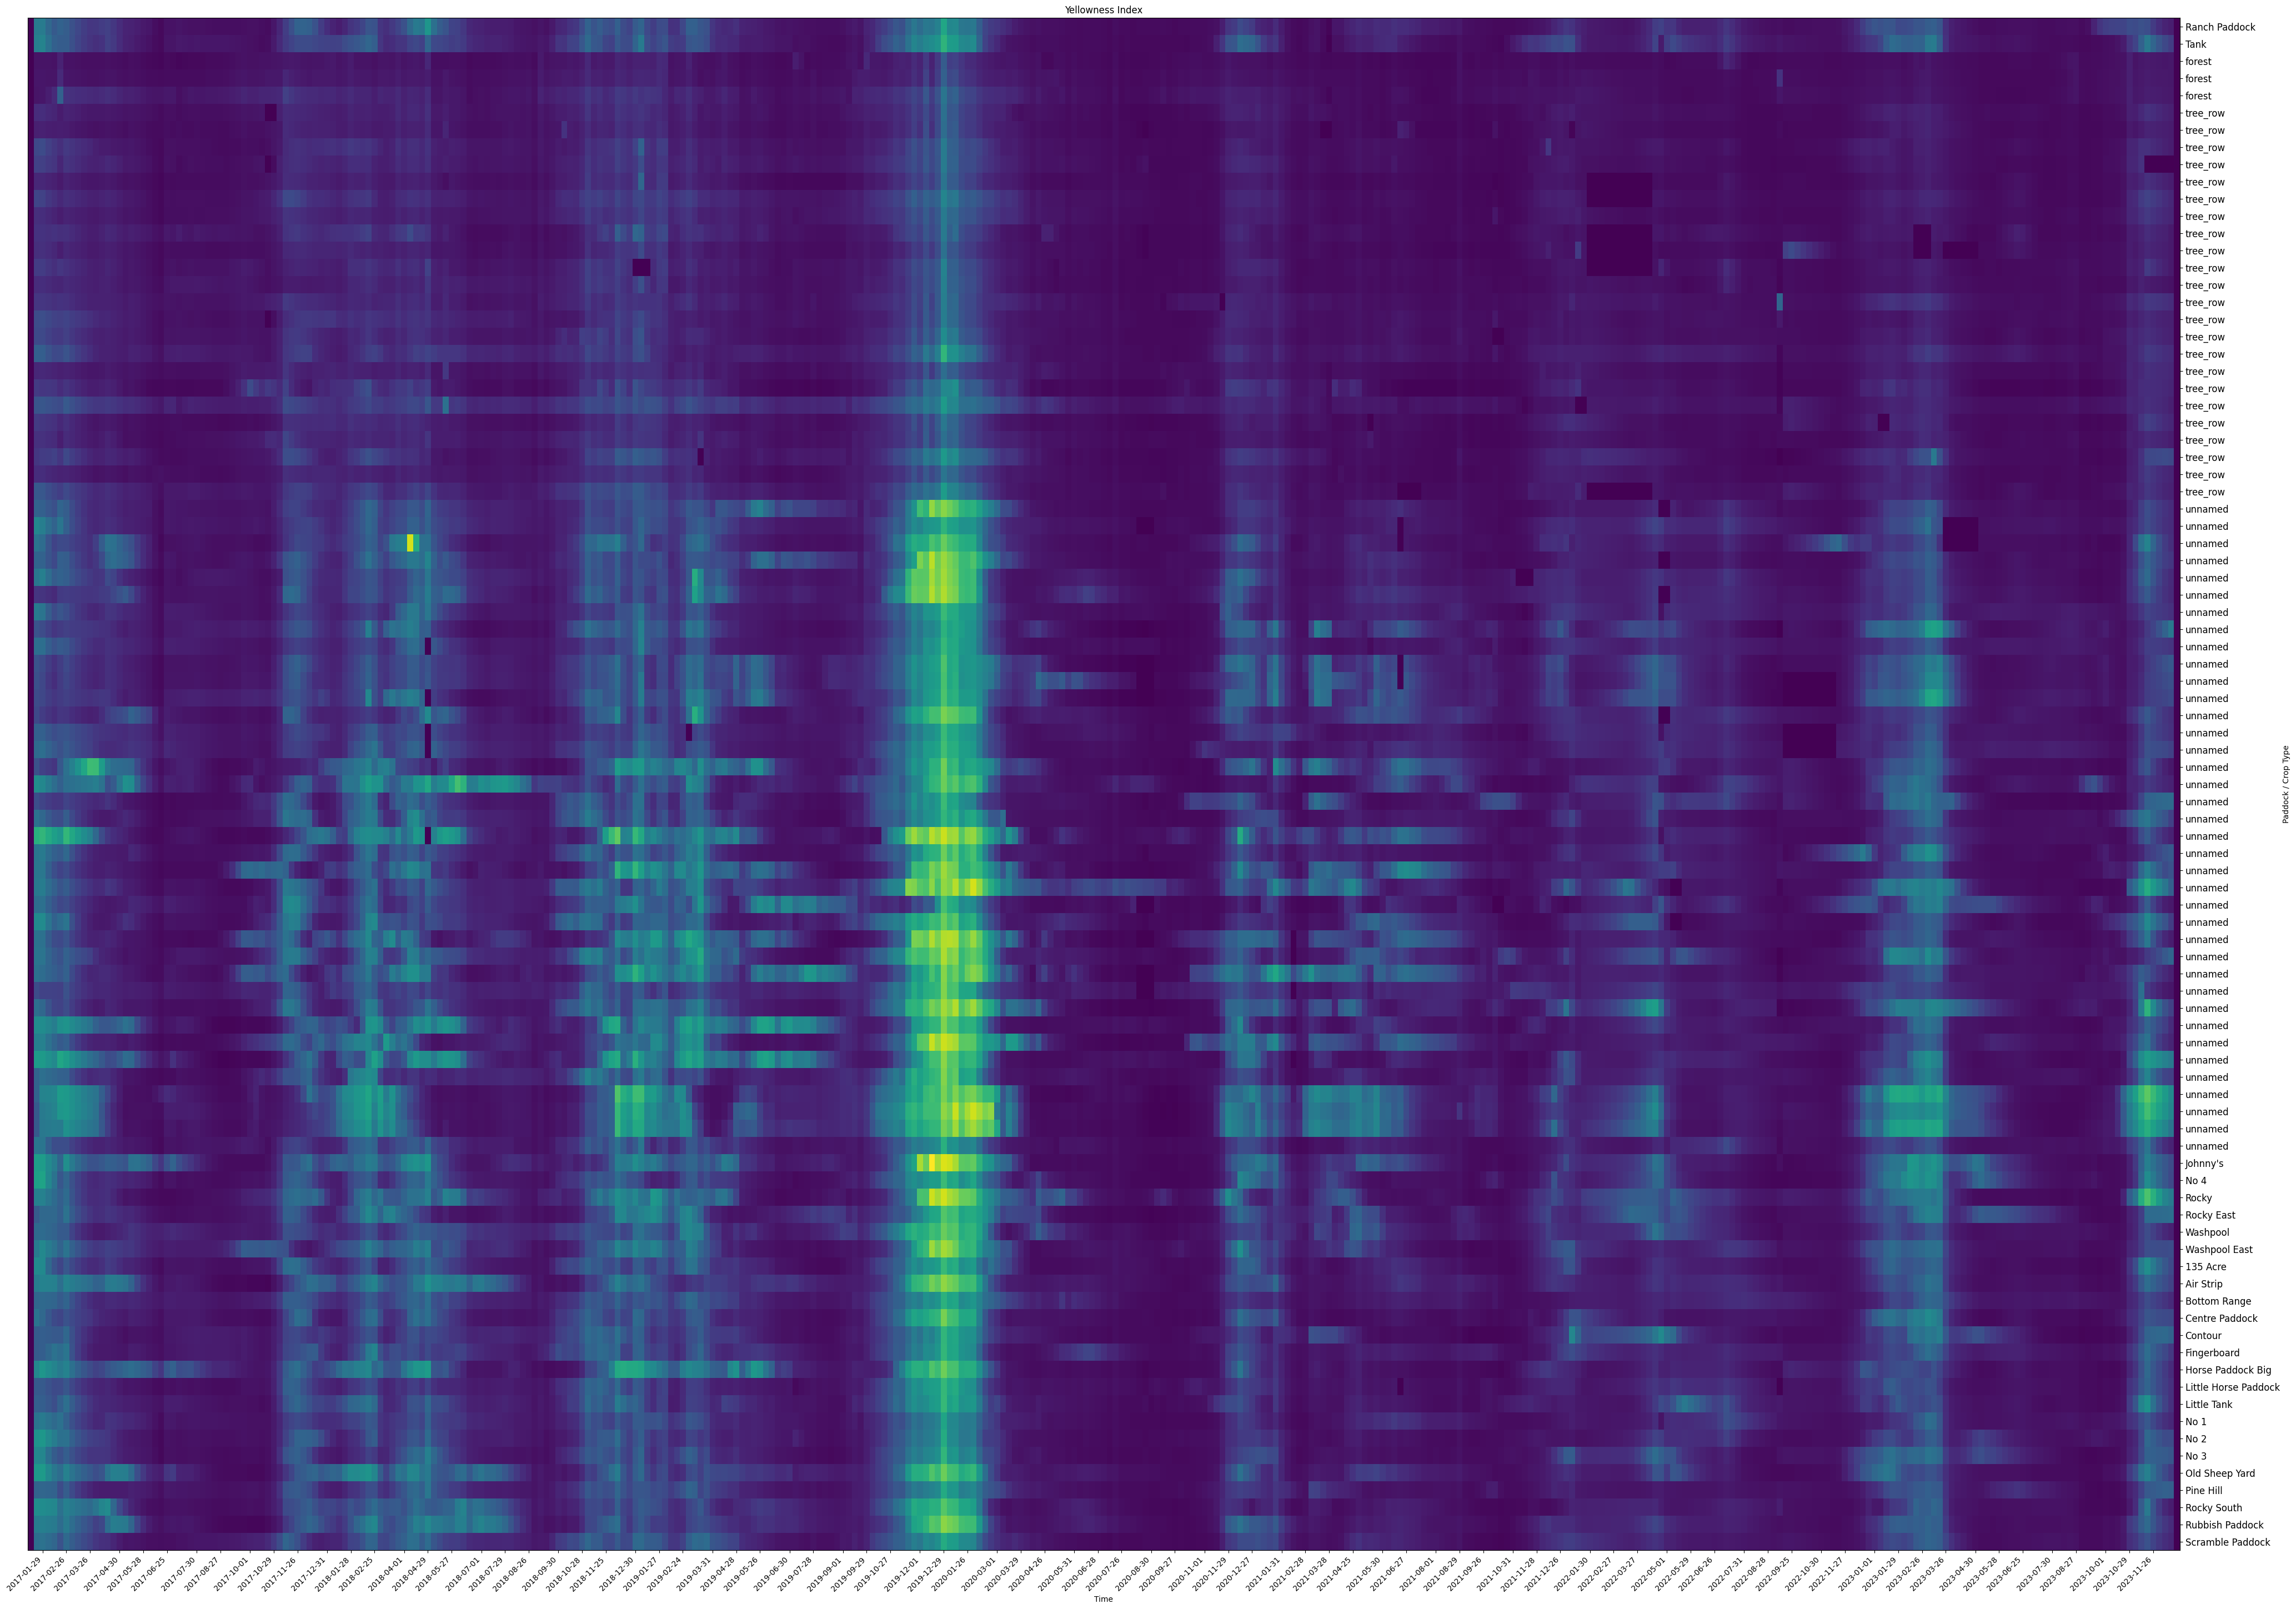

In [148]:
# # Create some row names for consistency across years
# ds_weekly_paddocks_named = ds_weekly_paddocks.where(ds_weekly_paddocks['type'] == 'named', drop=True)
# plot_clustermap_frac(ds_paddocks=ds_weekly_paddocks_named, variable_names=['bare', 'photosynthetic', 'non_photosynthetic'], exaggerate=True)
# ds_paddocks=ds_weekly_paddocks_named
ds_paddocks=ds_weekly_paddocks
variable=['NDYI2']
exaggerate=True

pt_variable = ds_paddocks.sel(variable=variable).pvt.values
pt_variable = np.apply_along_axis(
    lambda x: pd.Series(x).interpolate(method='linear', limit_direction='both').to_numpy(), 
    axis=1, 
    arr=pt_variable
)
pt_variable = np.nan_to_num(pt_variable, nan=0)

# Now a single band image instead of RGB, but keeping the variable name for simplicity
rgb_image = pt_variable.reshape([pt_variable.shape[0],pt_variable.shape[2]])

# Extract the timestamps and convert to Pandas DatetimeIndex
time_stamps = ds_paddocks.time.values
time_index = pd.to_datetime(time_stamps)

# Adjust start date to include January if necessary
start_date = time_index.min()
if start_date.month != 1:
    start_date = pd.Timestamp(year=start_date.year, month=1, day=1)

# Ensure January is included in monthly_start
monthly_start = pd.date_range(start=start_date, end=time_index.max(), freq='MS')

# Find the closest previous timestamps in the original time_index
monthly_ticks = []
for date in monthly_start:
    prior_dates = time_index[time_index <= date]
    if not prior_dates.empty:
        monthly_ticks.append(prior_dates[-1])

monthly_ticks_str = [str(t)[:10] for t in monthly_ticks]

# Get paddock names
row_names = ds_paddocks.name.values

df = df_sorted

# row_order = df.index.get_indexer(df.index)
row_order = df.index.to_list()
print(row_order)

# # # Reorder the RGB image and row labels according to the clustering
rgb_image_ordered = rgb_image[row_order, :]
ordered_row_names = list(df['Name'])
    
# Calculate the aspect ratio
num_rows, num_cols = rgb_image_ordered.shape[:2]
aspect_ratio = ((num_cols / num_rows)/ 5) * 89/25
# aspect_ratio = ((num_cols / num_rows)/ 5)


# Plot the RGB heatmap
fig, ax = plt.subplots(figsize=(50, 50))

im = ax.imshow(rgb_image_ordered, aspect=aspect_ratio)

# Customize the plot
font_size = 12
ax.set_xticks(ticks=[time_index.get_loc(t) for t in monthly_ticks])
ax.set_xticklabels(monthly_ticks_str, rotation=45, ha='right')

# Set the y-ticks on the right side
ax.yaxis.tick_right()
ax.yaxis.set_label_position('right')
ax.set_yticks(ticks=np.arange(len(ordered_row_names)), labels=ordered_row_names, fontsize=8, rotation=0)
ax.set_yticklabels(ordered_row_names, fontsize=font_size, rotation=0)

# Set labels and title
ax.set_xlabel('Time')
ax.set_ylabel('Paddock / Crop Type')
ax.set_title('Yellowness Index')
ax.grid(False)

# Save the plot to results
filename = outdir + stub + f"_pt-{'fractional'}.png"
plt.savefig(filename, bbox_inches='tight')
print(filename)

In [54]:
%%time

def plot_clustermap_frac(ds_paddocks, variable_names, outdir, stub, exaggerate=True):

    pt_variables = []
    for variable in variable_names:
        pt_variable = ds_paddocks.sel(variable=variable).pvt.values
        pt_variable = np.apply_along_axis(
            lambda x: pd.Series(x).interpolate(method='linear', limit_direction='both').to_numpy(), 
            axis=1, 
            arr=pt_variable
        )
        pt_variable = np.nan_to_num(pt_variable, nan=0)
        pt_variables.append(pt_variable)

    pt_bare = pt_variables[0]
    pt_photosynthetic = pt_variables[1]
    pt_non_photosynthetic = pt_variables[2]

    if exaggerate:
        # This exaggerate any variables that don't show up much
        pt_bare_norm = (pt_bare - pt_bare.min()) / (pt_bare.max() - pt_bare.min())
        pt_photosynthetic_norm = (pt_photosynthetic - pt_photosynthetic.min()) / (pt_photosynthetic.max() - pt_photosynthetic.min())
        pt_non_photosynthetic_norm = (pt_non_photosynthetic - pt_non_photosynthetic.min()) / (pt_non_photosynthetic.max() - pt_non_photosynthetic.min())
        rgb_image = np.dstack((pt_bare_norm, pt_photosynthetic_norm, pt_non_photosynthetic_norm))
    else:
        rgb_image = np.dstack((pt_bare, pt_photosynthetic, pt_non_photosynthetic))
            
    # Extract the timestamps and convert to Pandas DatetimeIndex
    time_stamps = ds_paddocks.time.values
    time_index = pd.to_datetime(time_stamps)
    
    # Adjust start date to include January if necessary
    start_date = time_index.min()
    if start_date.month != 1:
        start_date = pd.Timestamp(year=start_date.year, month=1, day=1)
    
    # Ensure January is included in monthly_start
    monthly_start = pd.date_range(start=start_date, end=time_index.max(), freq='MS')
    
    # Find the closest previous timestamps in the original time_index
    monthly_ticks = []
    for date in monthly_start:
        prior_dates = time_index[time_index <= date]
        if not prior_dates.empty:
            monthly_ticks.append(prior_dates[-1])
    
    monthly_ticks_str = [str(t)[:10] for t in monthly_ticks]
    
    # Extract the crop type information for the specified year
    crop_col = f'{year}_Crop'
    the_crops = pad_manan[pad_manan['type'] == 'named'][crop_col].fillna('')
    the_crops = the_crops.apply(lambda x: x.strip() if isinstance(x, str) else x).replace('', '')
    
    # Get paddock names
    row_names = ds_paddocks.name.values
    
    # Merge paddock names and crop types for row labels
    if len(row_names) != len(the_crops):
        raise ValueError("The two lists must be of the same length.")
        
    # names_crops = [f"{r} / {c}" for r, c in zip(row_names, the_crops)]
    names_crops = row_names
    
    # Might be better to just order alphabetically when using multiple years?
    
    # # Perform clustering to reorder rows
    # Z = linkage(pt_photosynthetic, method='average', metric='euclidean')
    # row_order = leaves_list(Z)

    df = pad_manan[pad_manan['type'] == 'named'].fillna('')
    df_sorted = df.sort_values(['Pasture State', 'name'])
    row_order = df_sorted.index.get_indexer(df.index)
    
    # # # Reorder the RGB image and row labels according to the clustering
    rgb_image_ordered = rgb_image[row_order, :, :]
    ordered_row_names = [names_crops[i] for i in row_order]
        
    # Calculate the aspect ratio
    num_rows, num_cols = rgb_image_ordered.shape[:2]
    aspect_ratio = (num_cols / num_rows) / 5
    
    # Plot the RGB heatmap
    fig, ax = plt.subplots(figsize=(50, 50))
    im = ax.imshow(rgb_image_ordered, aspect=aspect_ratio)
    
    # Customize the plot
    font_size = 12
    ax.set_xticks(ticks=[time_index.get_loc(t) for t in monthly_ticks])
    ax.set_xticklabels(monthly_ticks_str, rotation=45, ha='right')
    
    # Set the y-ticks on the right side
    ax.yaxis.tick_right()
    ax.yaxis.set_label_position('right')
    ax.set_yticks(ticks=np.arange(len(ordered_row_names)), labels=ordered_row_names, fontsize=8, rotation=0)
    ax.set_yticklabels(ordered_row_names, fontsize=font_size, rotation=0)
    
    # Set labels and title
    ax.set_xlabel('Time')
    ax.set_ylabel('Paddock / Crop Type')
    ax.set_title('Fractional Cover')
    ax.grid(False)
    
    # Save the plot to results
    filename = outdir + stub + f"_pt-{'fractional'}.png"
    plt.savefig(filename, bbox_inches='tight')
    print(filename)
    
# ds_weekly_paddocks_named = ds_weekly_paddocks.where(ds_weekly_paddocks['type'] == 'named', drop=True)
plot_clustermap_frac(ds_paddocks=ds_weekly_paddocks, variable_names=['bare', 'photosynthetic', 'non_photosynthetic'], outdir=outdir, stub=stub+"_"+'all_years'+'_heatmap_dendro_frac', exaggerate=True)

ValueError: The two lists must be of the same length.

In [53]:
def plot_clustermap2(ds_paddocks, variable_name, outdir, stub):
    '''This version only shows the named paddocks, and therefore does not color rows by 'type'.
    Also, attach crop type to the row label. 
    Put colour bar above plot to make more room for row labels...
    '''
    # Check if the variable_name exists in the dataset
    if variable_name not in ds_paddocks.variable.values:
        raise ValueError(f"Variable '{variable_name}' not found in the dataset.")
    
    # Extract the time series for the specified variable for all paddocks
    pt_variable = ds_paddocks.sel(variable=variable_name).pvt.values
    
    # Interpolate missing values along the time axis (2nd axis)
    pt_variable = np.apply_along_axis(
        lambda x: pd.Series(x).interpolate(method='linear', limit_direction='both').to_numpy(), 
        axis=1, 
        arr=pt_variable
    )

    print(pt_variable.shape)
    # Count NaN values
    nan_count = np.sum(np.isnan(pt_variable))
    print(f"Number of NaN values: {nan_count}")
    print("replacing nans with 0, for now, so the clustering can work..")
    pt_variable = np.nan_to_num(pt_variable, nan=0)

    # Extract the timestamps and convert to Pandas DatetimeIndex
    time_stamps = ds_paddocks.time.values
    time_index = pd.to_datetime(time_stamps)

    # Adjust start date to include January if necessary
    start_date = time_index.min()
    if start_date.month != 1:
        start_date = pd.Timestamp(year=start_date.year, month=1, day=1)
    
    # Ensure January is included in monthly_start
    monthly_start = pd.date_range(start=start_date, end=time_index.max(), freq='MS')

    # Find the closest previous timestamps in the original time_index
    monthly_ticks = []
    for date in monthly_start:
        prior_dates = time_index[time_index <= date]
        if not prior_dates.empty:
            monthly_ticks.append(prior_dates[-1])

    monthly_ticks_str = [str(t)[:10] for t in monthly_ticks]

    # Extract the crop type information for the specified year
    crop_col = f'{year}_Crop'
    the_crops = pad_manan[pad_manan['type'] == 'named'][crop_col].fillna('') #crops planted this year for named paddocks only. 
    the_crops = the_crops.apply(lambda x: x.strip() if isinstance(x, str) else x).replace('', '')

    # get paddock names
    row_names = ds_paddocks.name.values
    
    # Merge paddock names and crop types for row labels
    if len(row_names) != len(the_crops):
        raise ValueError("The two lists must be of the same length.")
        
    names_crops = ds_paddocks.name.values # [f"{r} / {c}" for r, c in zip(row_names, the_crops)]
    
    # Plot heatmap with clustering of the rows
    plt.figure(figsize=(6, 12))  # Adjust the figure size as needed

    # Get the order of the rows after clustering
    # row_order = g.dendrogram_row.reordered_ind

    # # Reorder the row names according to the clustering
    # ordered_row_names = [names_crops[i] for i in row_order]

    df = pad_manan[pad_manan['type'] == 'named'].fillna('')
    df_sorted = df.sort_values(['Pasture State', 'name'])
    row_order = df_sorted.index.get_indexer(df.index)
    
    # # # Reorder the RGB image and row labels according to the clustering
    rgb_image_ordered = rgb_image[row_order, :, :]
    ordered_row_names = [names_crops[i] for i in row_order]


    g = sns.clustermap(pt_variable, method='average', metric='euclidean', 
                   row_cluster=True, col_cluster=False, cmap='viridis')

    # Customize the plot
    g.ax_heatmap.set_xlabel('Time')

    # Set the x-tick labels to the closest previous valid timestamp of each month
    tick_positions = [time_index.get_loc(t) for t in monthly_ticks]
    g.ax_heatmap.set_xticks(tick_positions)
    g.ax_heatmap.set_xticklabels(monthly_ticks_str, rotation=45, ha='right')

    # Set the y-tick labels to the ordered paddock IDs
    g.ax_heatmap.set_yticks(np.arange(len(ordered_row_names)) + 0.5)
    g.ax_heatmap.set_yticklabels(ordered_row_names, fontsize=8, rotation=0)
    g.cax.set_title(variable_name, pad=10)  # Title above the color bar

    # Save the plot to results
    plt.savefig(outdir + stub + f"_pt-{variable_name}.png", bbox_inches='tight')

    # Print the number of missing pixels across all time series for the variable
    print(f'Number of missing pixels across all {variable_name} time series:', np.count_nonzero(np.isnan(pt_variable)))

ds_weekly_paddocks_named = ds_weekly_paddocks.where(ds_weekly_paddocks['type'] == 'named', drop=True)
the_var='NDYI2'
plot_clustermap2(ds_paddocks=ds_weekly_paddocks_named, variable_name=the_var, outdir=outdir, stub=stub+"_"+str(year)+'_heatmap_dendro_'+the_var+'_namedpaddocks')


(25, 363)
Number of NaN values: 0
replacing nans with 0, for now, so the clustering can work..


ValueError: Must pass 2-d input. shape=(25, 363, 3)

<Figure size 600x1200 with 0 Axes>

In [47]:
ds_weekly_paddocks_named

<xarray.Dataset>
Dimensions:   (paddock: 25, variable: 50, time: 363)
Coordinates:
  * paddock   (paddock) int64 38 39 40 41 42 43 44 46 ... 57 58 59 60 61 62 63
  * time      (time) datetime64[ns] 2017-01-15 2017-01-22 ... 2023-12-24
  * variable  (variable) object 'nbart_coastal_aerosol' ... 'non_photosynthetic'
Data variables:
    pvt       (paddock, variable, time) float64 nan 477.7 528.8 ... 0.4915 nan
    geometry  (paddock) object POLYGON ((14325453.540834494 -4132418.56074070...
    name      (paddock) object 'No 1' 'Tank' ... 'Fingerboard' "Johnny's"
    type      (paddock) object 'named' 'named' 'named' ... 'named' 'named'

In [ ]:

# def plot_time_series(ds_paddocks, bands, pad_manan, year, outdir, stub):
#     ''' Plot time series curves for multiple specified bands in a multi-panel interactive plot. '''
    
#     # Extract the time values
#     time_values = pd.to_datetime(ds_paddocks.time.values)
    
#     # Get the paddock values from ds_paddocks
#     paddock_values = ds_paddocks.paddock.values
    
#     # Subset pad_manan to only include rows with paddocks in ds_paddocks
#     pad_manan_subset = pad_manan[pad_manan['paddock'].isin(paddock_values)]
    
#     # Extract the crop type information for the specified year
#     crop_col = f'{year}_Crop'
#     pad_manan_subset[crop_col] = pad_manan_subset[crop_col].apply(lambda x: 'Unknown' if pd.isna(x) or x.strip() == '' else x)
#     crop_types = pad_manan_subset.set_index('paddock')[crop_col].to_dict()
    
#     # Identify unique crop types excluding 'Unknown'
#     unique_crop_types = pad_manan_subset[crop_col].unique()
#     unique_crop_types = [ct for ct in unique_crop_types if ct != 'Unknown']
    
#     # Create a color map for each unique crop type
#     colors = px.colors.qualitative.Plotly  # You can choose a different color palette if needed
#     num_colors = len(colors)
#     color_map = {crop_type: colors[i % num_colors] for i, crop_type in enumerate(unique_crop_types)}
#     color_map['Unknown'] = 'lightgrey'  # Assign light grey to 'Unknown'
    
#     # Create subplots, one for each specified band
#     fig = make_subplots(
#         rows=len(bands), cols=1, 
#         shared_xaxes=True, 
#         vertical_spacing=0.05,
#         subplot_titles=[None] * len(bands)
#     )
    
#     # Iterate over each specified band to create the subplots
#     for i, band in enumerate(bands):
#         if band not in ds_paddocks.variable.values:
#             raise ValueError(f"Band '{band}' not found in the dataset.")
        
#         # Extract data for the current band
#         band_data = ds_paddocks.sel(variable=band).pvt.values
        
#         # Add traces for each paddock
#         for paddock_index, paddock_name in enumerate(ds_paddocks.name.values):
#             paddock_id = paddock_values[paddock_index]
#             crop_type = crop_types.get(paddock_id, 'Unknown')
#             line_color = color_map.get(crop_type, 'lightgrey')
            
#             # Print for debugging
#             #print(paddock_name, crop_type, dict(color=line_color))
            
#             hover_text = f'Paddock: {paddock_name}<br>Crop: {crop_type}'
#             fig.add_trace(
#                 go.Scatter(
#                     x=time_values,
#                     y=band_data[paddock_index],
#                     mode='lines',
#                     name=f'Paddock {paddock_name}',
#                     line=dict(color=line_color),
#                     hoverinfo='text',
#                     text=hover_text
#                 ),
#                 row=i+1, col=1
#             )
        
#         # Update y-axis title for each subplot
#         fig.update_yaxes(title_text=band, row=i+1, col=1)
    
#     # Update layout
#     fig.update_layout(
#         height=300 * len(bands),  # Adjust height according to the number of subplots
#         title_text=(f"Year: {year}. Hover over lines to see paddock name and crop planted: {unique_crop_types}"),
#         showlegend=False,
#         plot_bgcolor='white',
#         paper_bgcolor='white',
#         margin=dict(l=50, r=50, t=50, b=50)
#     )
    
#     # Update the layout for a more classic look
#     fig.update_xaxes(showline=True, linewidth=1, linecolor='black', mirror=True)
#     fig.update_yaxes(showline=True, linewidth=1, linecolor='black', mirror=True)
#     fig.update_layout(
#         xaxis=dict(showgrid=False),
#         yaxis=dict(showgrid=False)
#     )
    
#     # Display the plot in the Jupyter Notebook
#     iplot(fig)
    
#     # Save the plot to a file and show it
#     output_file = outdir + stub + "_time_series.html"
#     plot(fig, filename=output_file, auto_open=False)
#     print(f"Interactive plot saved as {output_file}")
#     print(unique_crop_types)
# # Example usage:
# # bands = ['NDVI', 'NIRv', 'CFI3', 'NDTI2', 'CAI']  # Specify the bands you want to plot
# bands = ['NDVI', 'photosynthetic', 'non_photosynthetic']  # Specify the bands you want to plot
# plot_time_series(ds_paddocks=ds_weekly_paddocks_named, bands=bands, pad_manan=pad_manan, year=year, outdir=outdir, stub=stub+"_"+str(year))



In [ ]:
# named_pads = list(pad_man[pad_man['type'] == 'named'].name)
# named_pads

In [ ]:
# # Add fractional cover to the data series
# def calculate_fractional_cover(ds, band_names, i):
#     """
#     Calculate the fractional cover using specified bands from an xarray Dataset.

#     Parameters:
#     ds (xarray.Dataset): The input xarray Dataset containing the satellite data.
#     band_names (list): A list of 6 band names to use for the calculation.
#     i (int): The integer specifying which pretrained model to use.

#     Returns:
#     numpy.ndarray: The output array with fractional cover (time, bands, x, y).
#     """
#     # Check if the number of band names is exactly 6
#     if len(band_names) != 6:
#         raise ValueError("Exactly 6 band names must be provided")
    
#     # Extract the specified bands and stack them into a numpy array with shape (time, bands, x, y)
#     inref = np.stack([ds[band].values for band in band_names], axis=1)
#     print(inref.shape)  # This should now be (time, bands, x, y)

#     inref = inref * 0.0001

#     # Initialize an array to store the fractional cover results
#     fractions = np.empty((inref.shape[0], 3, inref.shape[2], inref.shape[3]))

#     # Loop over each time slice and apply the unmix_fractional_cover function
#     for t in range(inref.shape[0]):
#         fractions[t] = unmix_fractional_cover(inref[t], fc_model=data.get_model(n=i))
    
#     return fractions

# def add_fractional_cover_to_ds(ds, fractions):
#     """
#     Add the fractional cover bands to the original xarray.Dataset.

#     Parameters:
#     ds (xarray.Dataset): The original xarray Dataset containing the satellite data.
#     fractions (numpy.ndarray): The output array with fractional cover (time, bands, x, y).

#     Returns:
#     xarray.Dataset: The updated xarray Dataset with the new fractional cover bands.
#     """
#     # Create DataArray for each vegetation fraction
#     bg = xr.DataArray(fractions[:, 0, :, :], coords=[ds.coords['time'], ds.coords['y'], ds.coords['x']], dims=['time', 'y', 'x'])
#     pv = xr.DataArray(fractions[:, 1, :, :], coords=[ds.coords['time'], ds.coords['y'], ds.coords['x']], dims=['time', 'y', 'x'])
#     npv = xr.DataArray(fractions[:, 2, :, :], coords=[ds.coords['time'], ds.coords['y'], ds.coords['x']], dims=['time', 'y', 'x'])
    
#     # Assign new DataArrays to the original Dataset
#     ds_updated = ds.assign(bg=bg, pv=pv, npv=npv)
    
#     return ds_updated


# band_names = ['nbart_blue', 'nbart_green', 'nbart_red', 'nbart_nir_1', 'nbart_swir_2', 'nbart_swir_3']

# with open(john_outdir+stub+'_ds2.pkl', 'rb') as handle:
#     ds = pickle.load(handle)[band_names]

# # Resample data weekly
# ds = ds.resample(time="1W").interpolate("linear")

# print('No. weeks in time series:', len(ds_weekly.time.values))

# i = 3  
# fractions = calculate_fractional_cover(ds, band_names, i)
# ds_updated = add_fractional_cover_to_ds(ds, fractions)
# print(ds_updated)

# with open(chris_outdir+stub+'_ds_weekly_fractions.pkl', 'wb') as handle:
#     pickle.dump(ds_updated, handle, protocol=pickle.HIGHEST_PROTOCOL)

# # Took about 10 mins
# chris_outdir+stub+'_ds_weekly_fractions.pkl'

In [ ]:
# ds_notinfinity = xr.where(np.isinf(ds_updated), np.nan, ds_updated)
# ds_cleaned = ds_notinfinity.dropna(dim='time', how='all', subset=['nbart_blue'])

In [ ]:
# with open(chris_outdir+stub+'_ds_weekly_fractions.pkl', 'wb') as handle:
#     pickle.dump(ds_cleaned, handle, protocol=pickle.HIGHEST_PROTOCOL)

# # Not sure why I can't save a pickle file with the new fractional cover bands added
# with open(chris_outdir+stub+'_ds_weekly_fractions.pkl') as handle:
#     ds = pickle.load(handle)

In [ ]:
# # Calendar plot of fractional cover
# def prepare_dataset(ds):
#     """Reads and prepares the satellite data (xarray) for further processing (e.g. calendar plots)."""
    
#     band_names = ['bg', 'pv', 'npv']

#     # ds_weekly_allyears = ds.resample(time="1W").interpolate("linear")
#     ds_weekly_allyears = ds

#     # Determine the earliest time point in ds_weekly
#     earliest_time = ds_weekly_allyears.time.values[0]

#     # Create new time steps in 7-day increments before the earliest time, as long as the dates are in 2017
#     new_time_steps = []
#     current_time = pd.Timestamp(earliest_time) - pd.Timedelta(days=7)
#     while current_time.year == 2017:
#         new_time_steps.append(current_time)
#         current_time -= pd.Timedelta(days=7)

#     # Reverse the order of new_time_steps to ensure they are in ascending order
#     new_time_steps = new_time_steps[::-1]

#     # Create a new xarray Dataset for these additional time steps with NaN values
#     nan_data_vars = {var: (('time',) + ds_weekly_allyears[var].dims[1:], np.full((len(new_time_steps),) + ds_weekly_allyears[var].shape[1:], np.nan)) for var in ds_weekly_allyears.data_vars}
#     new_coords = {coord: ds_weekly_allyears.coords[coord] for coord in ds_weekly_allyears.coords if coord != 'time'}
#     new_ds = xr.Dataset(
#         data_vars=nan_data_vars,
#         coords={**new_coords, 'time': new_time_steps}
#     )

#     # Concatenate the new dataset with ds_weekly
#     ds_weekly_allyears = xr.concat([new_ds, ds_weekly_allyears], dim='time')

#     return ds_weekly_allyears

# ds_weekly_allyears = prepare_dataset(ds_cleaned)

In [ ]:
# ds_weekly_allyears_cleaned = ds_weekly_allyears.dropna(dim='time', how='all', subset=['bg'])
# ds_weekly_allyears_frac = ds_weekly_allyears_cleaned[['bg', 'pv', 'npv']]
# ds_weekly_allyears_crs = ds_weekly_allyears_frac.rio.write_crs(6933)

In [ ]:
# def calendar_plots(ds_weekly_allyears, pad_names, outdir, stub, pad_man):
#     '''Generates 'calendar plots' (week by year RGB) paddocks specified in pad_names. Also includes option to use paddock ID instead of name.
#     This can be used to visualize phenology across years for the same paddock.
#     '''
#     # List of paddock names to loop through
#     print(pad_names)

#     # bands = ['nbart_red', 'nbart_green', 'nbart_blue']
#     bands = ['bg', 'pv', 'npv']
    
#     # Loop through each geometry in pad_man where 'name' is in pad_names
#     for idx, row in pad_man[pad_man['name'].isin(pad_names)].iterrows():
#         geometry = row['geometry']
#         paddock_id = row['paddock']
#         paddock_name = row['name']
#         print(paddock_id, paddock_name, geometry)
    
#         # Clip the dataset to the current geometry
#         clipped_ds = ds_weekly_allyears.rio.clip([mapping(geometry)])
        
#         # Select only the red, green, and blue bands
#         # clipped_ds_rgb = clipped_ds[['nbart_red', 'nbart_green', 'nbart_blue']]
#         clipped_ds_rgb = clipped_ds[bands]

#         # Remove any time steps in 2024
#         clipped_ds_rgb = clipped_ds_rgb.sel(time=clipped_ds_rgb['time'].dt.year != 2024)

#         # Replace NaN values with 0
#         clipped_ds_rgb = clipped_ds_rgb.fillna(0)
    
#         # Create output filename
#         out_name = outdir + stub + '_calendar_' + paddock_name + '.png'
        
#         # Run xr_animation
#         rgb(clipped_ds_rgb, 
#             # bands=['nbart_red', 'nbart_green', 'nbart_blue'], 
#             bands=bands, 
#             robust=True, 
#             size=4,
#             col="time", 
#             col_wrap=52,  # weekly
#             savefig_path=out_name)
#         print('Finished: ', paddock_name)

# pad_names = ["Rocky", "Rocky_East", "Scramble_Paddock", "Washpool_East"]
# calendar_plots(ds_weekly_allyears_crs, pad_names, outdir, stub, pad_man) # Took 20 mins (about 5 mins per paddock)